# Activity 1.2 : Training Neural Networks


#### Objective(s):

This activity aims to demonstrate how to train neural networks using keras

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to build and train neural networks 
* Demonstrate how to evaluate and plot the model using training and validation loss


#### Resources:
* Jupyter Notebook

CI Pima Diabetes Dataset

* pima-indians-diabetes.csv


#### Procedures

Load the necessary libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns

%matplotlib inline

In [2]:
## Import Keras objects for Deep Learning

from keras.models  import Sequential
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam, SGD, RMSprop

Load the dataset

In [3]:

filepath = "pima-indians-diabetes.csv"
names = ["times_pregnant", "glucose_tolerance_test", "blood_pressure", "skin_thickness", "insulin", 
         "bmi", "pedigree_function", "age", "has_diabetes"]
diabetes_df = pd.read_csv(filepath, names=names)

Check the top 5 samples of the data

In [4]:

print(diabetes_df.shape)
diabetes_df.sample(5)

(768, 9)


,times_pregnant,glucose_tolerance_test,blood_pressure,skin_thickness,insulin,bmi,pedigree_function,age,has_diabetes
307,0,137,68,14,148,24.8,0.143,21,0
11,10,168,74,0,0,38.0,0.537,34,1
152,9,156,86,28,155,34.3,1.189,42,1
552,6,114,88,0,0,27.8,0.247,66,0
690,8,107,80,0,0,24.6,0.856,34,0


In [5]:
diabetes_df.dtypes

times_pregnant              int64
glucose_tolerance_test      int64
blood_pressure              int64
skin_thickness              int64
insulin                     int64
bmi                       float64
pedigree_function         float64
age                         int64
has_diabetes                int64
dtype: object

In [6]:
X = diabetes_df.iloc[:, :-1].values
y = diabetes_df["has_diabetes"].values

Split the data to Train, and Test (75%, 25%)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11111)

In [8]:
np.mean(y), np.mean(1-y)

(np.float64(0.3489583333333333), np.float64(0.6510416666666666))

Build a single hidden layer neural network using 12 nodes. 
Use the sequential model with single layer network and input shape to 8. 



Normalize the data

In [9]:
normalizer = StandardScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

Define the model:
* Input size is 8-dimensional
* 1 hidden layer, 12 hidden nodes, sigmoid activation 
* Final layer with one node and sigmoid activation (standard for binary classification)

In [10]:


model  = Sequential([
    Dense(12, input_shape=(8,), activation="sigmoid"),
    Dense(1, activation="sigmoid")
])

p:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


View the model summary 

In [11]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

Train the model 
* Compile the model with optimizer, loss function and metrics
* Use the fit function to return the run history. 


In [12]:

model.compile(SGD(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
run_hist_1 = model.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=200)


Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.3438 - loss: 0.7616 - val_accuracy: 0.3490 - val_loss: 0.7404
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3542 - loss: 0.7504 - val_accuracy: 0.3802 - val_loss: 0.7310
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3698 - loss: 0.7403 - val_accuracy: 0.3802 - val_loss: 0.7227
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3733 - loss: 0.7311 - val_accuracy: 0.4219 - val_loss: 0.7151
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4097 - loss: 0.7228 - val_accuracy: 0.4219 - val_loss: 0.7083
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4288 - loss: 0.7153 - val_accuracy: 0.4792 - val_loss: 0.7022
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4688 - loss: 0.7085 - val_accuracy: 0.5156 - val_loss: 0.6967
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5000 - loss: 0.7024 - val_accuracy: 0.546

In [13]:
## Like we did for the Random Forest, we generate two kinds of predictions
#  One is a hard decision, the other is a probabilitistic score.

y_pred_class_nn_1 = (model.predict(X_test_norm)>0.5).astype('int32')
y_pred_prob_nn_1 = model.predict(X_test_norm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [14]:
# Let's check out the outputs to get a feel for how keras apis work.
y_pred_class_nn_1[:10]

array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0]], dtype=int32)

In [15]:
y_pred_prob_nn_1[:10]

array([[0.41149166],
       [0.54406655],
       [0.2918666 ],
       [0.26626804],
       [0.24775504],
       [0.53089446],
       [0.23917605],
       [0.36239496],
       [0.5009994 ],
       [0.36245355]], dtype=float32)

Create the plot_roc function

In [16]:
def plot_roc(y_test, y_pred, model_name):
    fpr, tpr, thr = roc_curve(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(fpr, tpr, 'k-')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=.5)  # roc curve for random model
    ax.grid(True)
    ax.set(title='ROC Curve for {} on PIMA diabetes problem'.format(model_name),
           xlim=[-0.01, 1.01], ylim=[-0.01, 1.01])



Evaluate the model performance and plot the ROC CURVE

accuracy is 0.729
roc-auc is 0.776


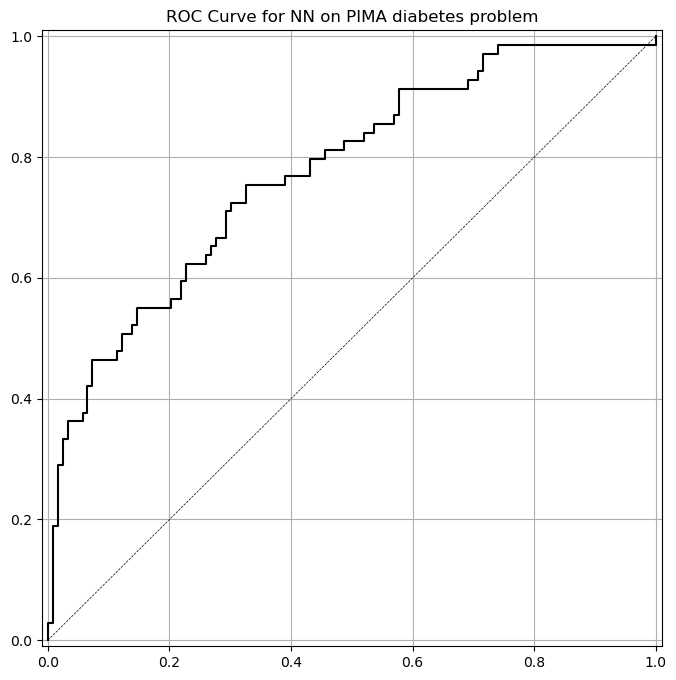

In [17]:

print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_1)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_1)))

plot_roc(y_test, y_pred_prob_nn_1, 'NN')

 Plot the training loss and the validation loss over the different epochs and see how it looks

In [19]:
run_hist_1.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

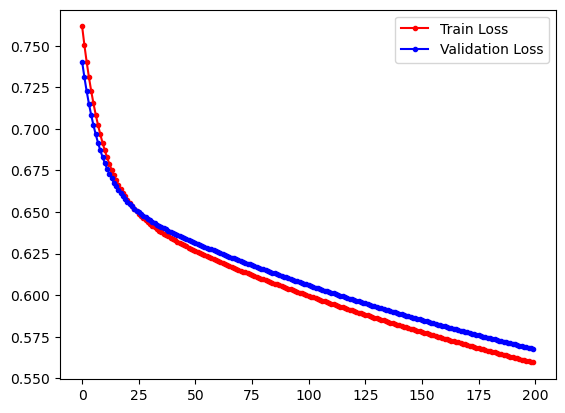

In [20]:
fig, ax = plt.subplots()
ax.plot(run_hist_1.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

What is your interpretation about the result of the train and validation loss?

<b> The graph shows that the train and validation loss did not have a large gap between their values, which made their curves consistent and essentially almost the same. This also means that there is no overfitting. 

#### Supplementary Activity

* Build a model with two hidden layers, each with 6 nodes
* Use the "relu" activation function for the hidden layers, and "sigmoid" for the final layer
* Use a learning rate of .003 and train for 1500 epochs
* Graph the trajectory of the loss functions, accuracy on both train and test set
* Plot the roc curve for the predictions
* Use different learning rates, numbers of epochs, and network structures. 
* Plot the results of training and validation loss using different learning rates, number of epocgs and network structures
* Interpret your result

In [21]:
# Build a model with two hidden layers, each with 6 nodes
# Use the "relu" activation function for the hidden layers, and "sigmoid" for the final layer

model_1 = Sequential([
    Dense(6, input_shape=(8,), activation="relu"),
    Dense(6, activation='relu'),
    Dense(1, activation="sigmoid")
])

p:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# Use a learning rate of 0.003 and train for 1500 epochs

model_1.compile(SGD(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
run_hist_2 = model_1.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=1500)

Epoch 1/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6649 - loss: 0.6066 - val_accuracy: 0.6562 - val_loss: 0.6148
Epoch 2/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.6032 - val_accuracy: 0.6562 - val_loss: 0.6126
Epoch 3/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6649 - loss: 0.5999 - val_accuracy: 0.6562 - val_loss: 0.6105
Epoch 4/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6632 - loss: 0.5968 - val_accuracy: 0.6562 - val_loss: 0.6085
Epoch 5/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6649 - loss: 0.5938 - val_accuracy: 0.6615 - val_loss: 0.6067
Epoch 6/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6667 - loss: 0.5910 - val_accuracy: 0.6615 - val_loss: 0.6050
Epoch 7/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6684 - loss: 0.5884 - val_accuracy: 0.6667 - val_loss: 0.6034
Epoch 8/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6701 - loss: 0.5858 - val_accur

In [23]:
y_pred_class_nn_2 = (model_1.predict(X_test_norm)>0.5).astype('int32')
y_pred_prob_nn_2 = model_1.predict(X_test_norm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


accuracy is 0.766
roc-auc is 0.819


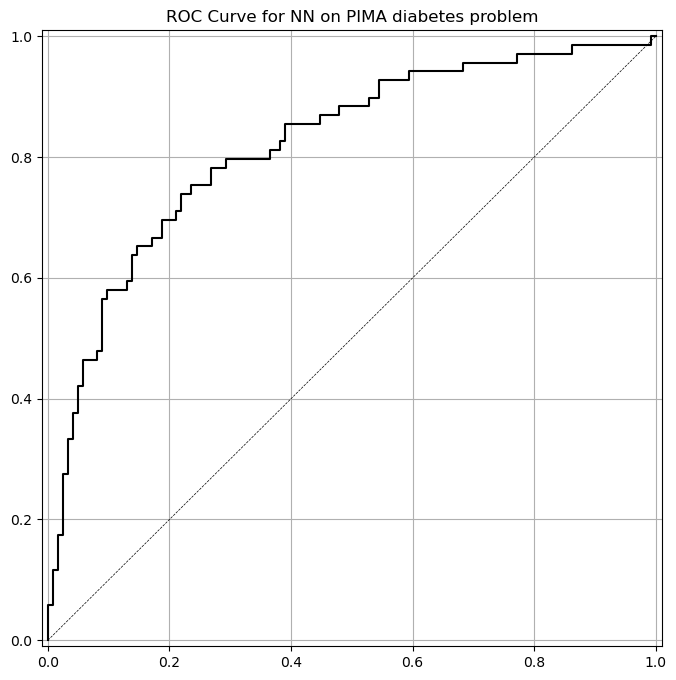

In [24]:
print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_2)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_2)))

plot_roc(y_test, y_pred_prob_nn_2, 'NN')

In [25]:
run_hist_2.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

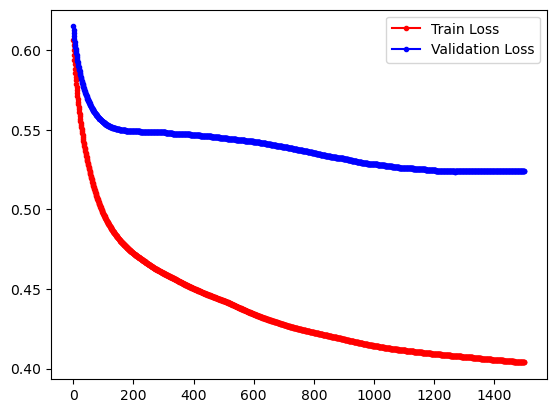

In [26]:
fig, ax = plt.subplots()
ax.plot(run_hist_2.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_2.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

In [28]:
from tensorflow.keras.regularizers import l2

model_2 = Sequential([
    Dense(6, activation="relu", input_shape=(8,), kernel_regularizer=l2(0.001)),
    Dense(6, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(1, activation="sigmoid")
])


p:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model_2.compile(Adam(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
run_hist_3 = model_2.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=300)

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6042 - loss: 0.7201 - val_accuracy: 0.6979 - val_loss: 0.6798
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6719 - loss: 0.6607 - val_accuracy: 0.7448 - val_loss: 0.6397
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7257 - loss: 0.6192 - val_accuracy: 0.7604 - val_loss: 0.6059
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7535 - loss: 0.5819 - val_accuracy: 0.7812 - val_loss: 0.5769
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7760 - loss: 0.5479 - val_accuracy: 0.7865 - val_loss: 0.5524
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7812 - loss: 0.5218 - val_accuracy: 0.7760 - val_loss: 0.5347
Epoch 7/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7882 - loss: 0.5053 - val_accuracy: 0.7604 - val_loss: 0.5238
Epoch 8/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7812 - loss: 0.4936 - val_accuracy: 0.7604

In [30]:
y_pred_class_nn_3 = (model_2.predict(X_test_norm)>0.5).astype('int32')
y_pred_prob_nn_3 = model_2.predict(X_test_norm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


accuracy is 0.760
roc-auc is 0.808


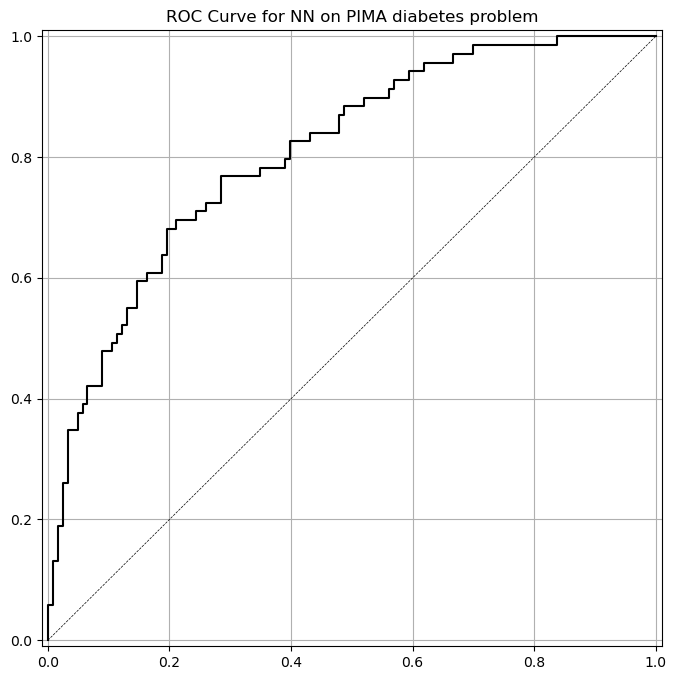

In [31]:
print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_3)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_3)))

plot_roc(y_test, y_pred_prob_nn_3, 'NN')

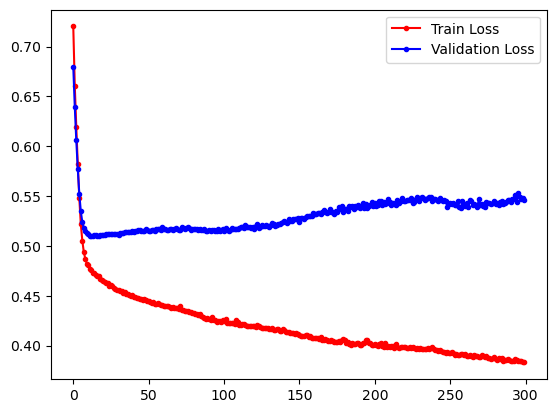

In [32]:
fig, ax = plt.subplots()
ax.plot(run_hist_3.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_3.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

In [33]:
model_3 = Sequential([
    Dense(8, activation="relu", input_shape=(8,), kernel_regularizer=l2(0.001)),
    Dense(1, activation="sigmoid")
])

p:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model_3.compile(Adam(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
run_hist_4 = model_3.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=250)

Epoch 1/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6615 - loss: 0.7126 - val_accuracy: 0.6354 - val_loss: 0.6786
Epoch 2/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6788 - loss: 0.6314 - val_accuracy: 0.6458 - val_loss: 0.6196
Epoch 3/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6997 - loss: 0.5826 - val_accuracy: 0.6719 - val_loss: 0.5862
Epoch 4/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7188 - loss: 0.5514 - val_accuracy: 0.6771 - val_loss: 0.5653
Epoch 5/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7257 - loss: 0.5279 - val_accuracy: 0.6927 - val_loss: 0.5537
Epoch 6/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7344 - loss: 0.5120 - val_accuracy: 0.7031 - val_loss: 0.5441
Epoch 7/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7483 - loss: 0.4996 - val_accuracy: 0.7188 - val_loss: 0.5382
Epoch 8/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7639 - loss: 0.4891 - val_accuracy: 0.7188

In [35]:
y_pred_class_nn_4 = (model_3.predict(X_test_norm)>0.5).astype('int32')
y_pred_prob_nn_4 = model_3.predict(X_test_norm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


accuracy is 0.760
roc-auc is 0.794


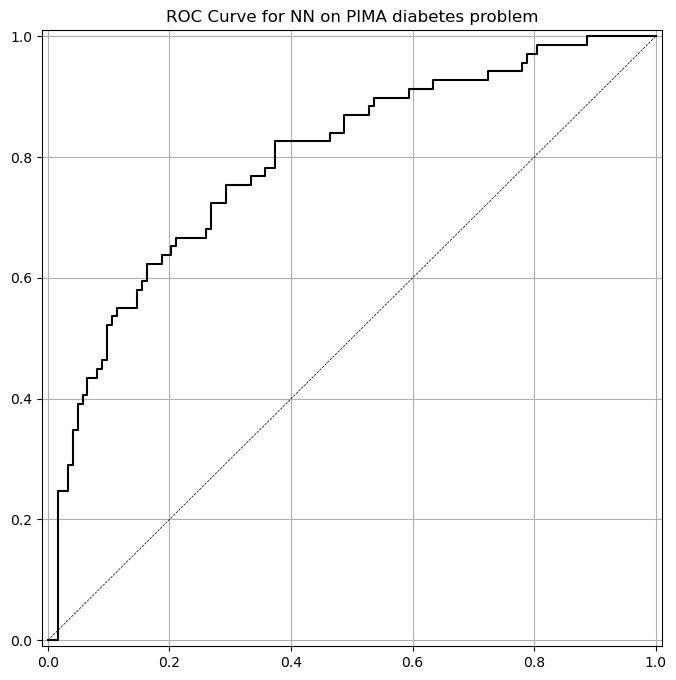

In [36]:
print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_4)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_4)))

plot_roc(y_test, y_pred_prob_nn_4, 'NN')

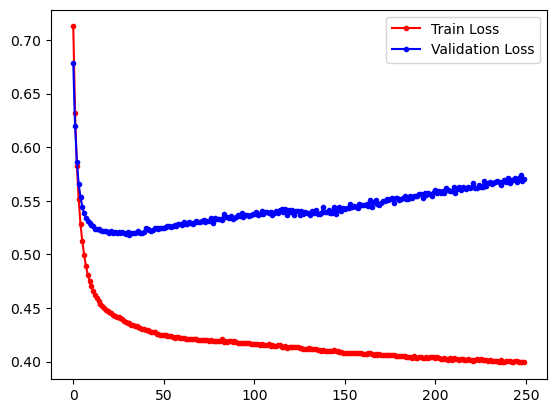

In [37]:
fig, ax = plt.subplots()
ax.plot(run_hist_4.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_4.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

In [38]:
from tensorflow.keras.layers import Dropout

model_4 = Sequential([
    Dense(6, activation="relu", input_shape=(8,), kernel_regularizer=l2(0.003)),
    Dropout(0.2),
    Dense(6, activation="relu", kernel_regularizer=l2(0.003)),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

p:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model_4.compile(Adam(learning_rate = .003), "binary_crossentropy", metrics=["accuracy"])
run_hist_5 = model_4.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=100)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5694 - loss: 0.7295 - val_accuracy: 0.6094 - val_loss: 0.7085
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6285 - loss: 0.6985 - val_accuracy: 0.6198 - val_loss: 0.6871
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6528 - loss: 0.6786 - val_accuracy: 0.6406 - val_loss: 0.6678
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6545 - loss: 0.6660 - val_accuracy: 0.6406 - val_loss: 0.6528
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6701 - loss: 0.6368 - val_accuracy: 0.6458 - val_loss: 0.6374
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6597 - loss: 0.6241 - val_accuracy: 0.6458 - val_loss: 0.6227
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6615 - loss: 0.6112 - val_accuracy: 0.6562 - val_loss: 0.6080
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6858 - loss: 0.5992 - val_accuracy: 0.

In [40]:
y_pred_class_nn_5 = (model_4.predict(X_test_norm)>0.5).astype('int32')
y_pred_prob_nn_5 = model_4.predict(X_test_norm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


accuracy is 0.755
roc-auc is 0.818


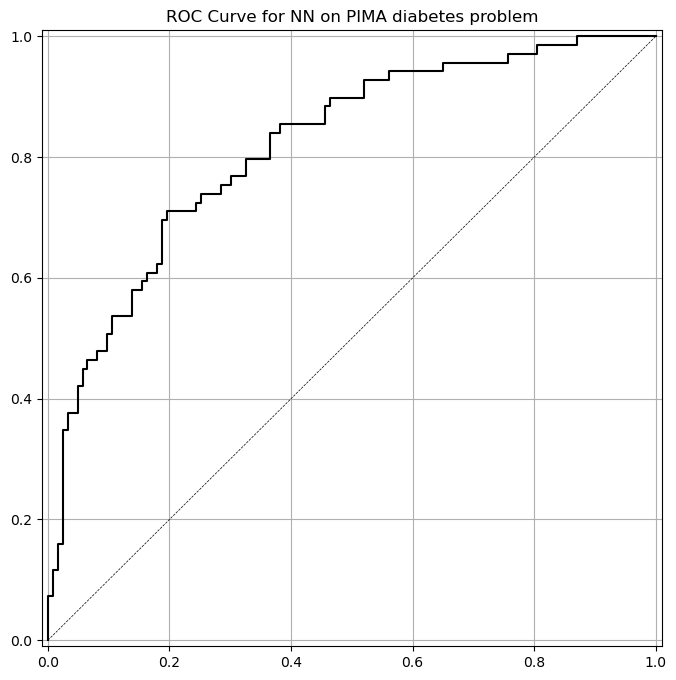

In [41]:
print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_5)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_5)))

plot_roc(y_test, y_pred_prob_nn_5, 'NN')

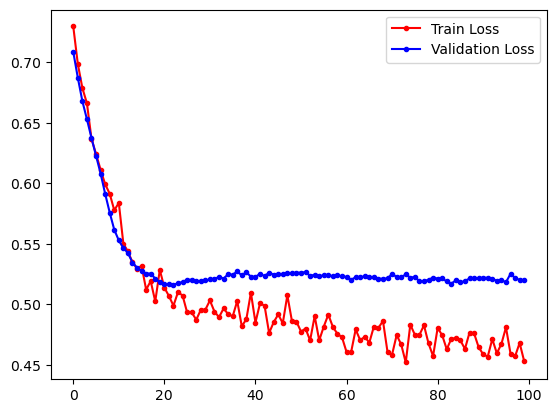

In [42]:
fig, ax = plt.subplots()
ax.plot(run_hist_5.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_5.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

In [45]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_prob, label, ax):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

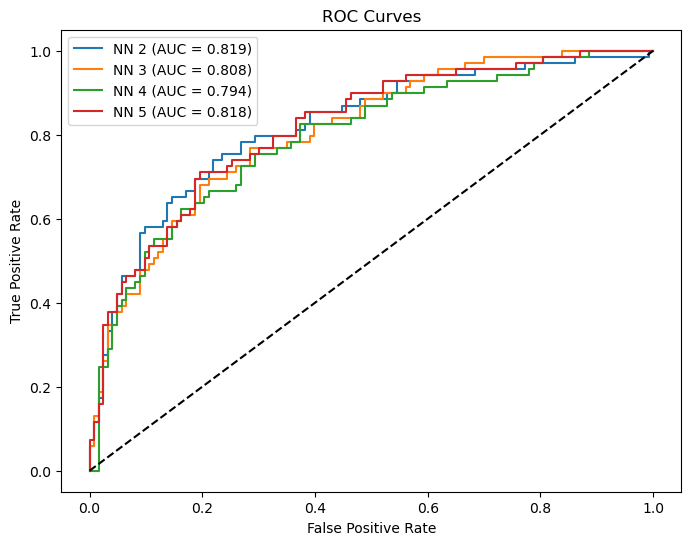

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_roc_curve(y_test, y_pred_prob_nn_2, "NN 2", ax)
plot_roc_curve(y_test, y_pred_prob_nn_3, "NN 3", ax)
plot_roc_curve(y_test, y_pred_prob_nn_4, "NN 4", ax)
plot_roc_curve(y_test, y_pred_prob_nn_5, "NN 5", ax)

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()
plt.show()

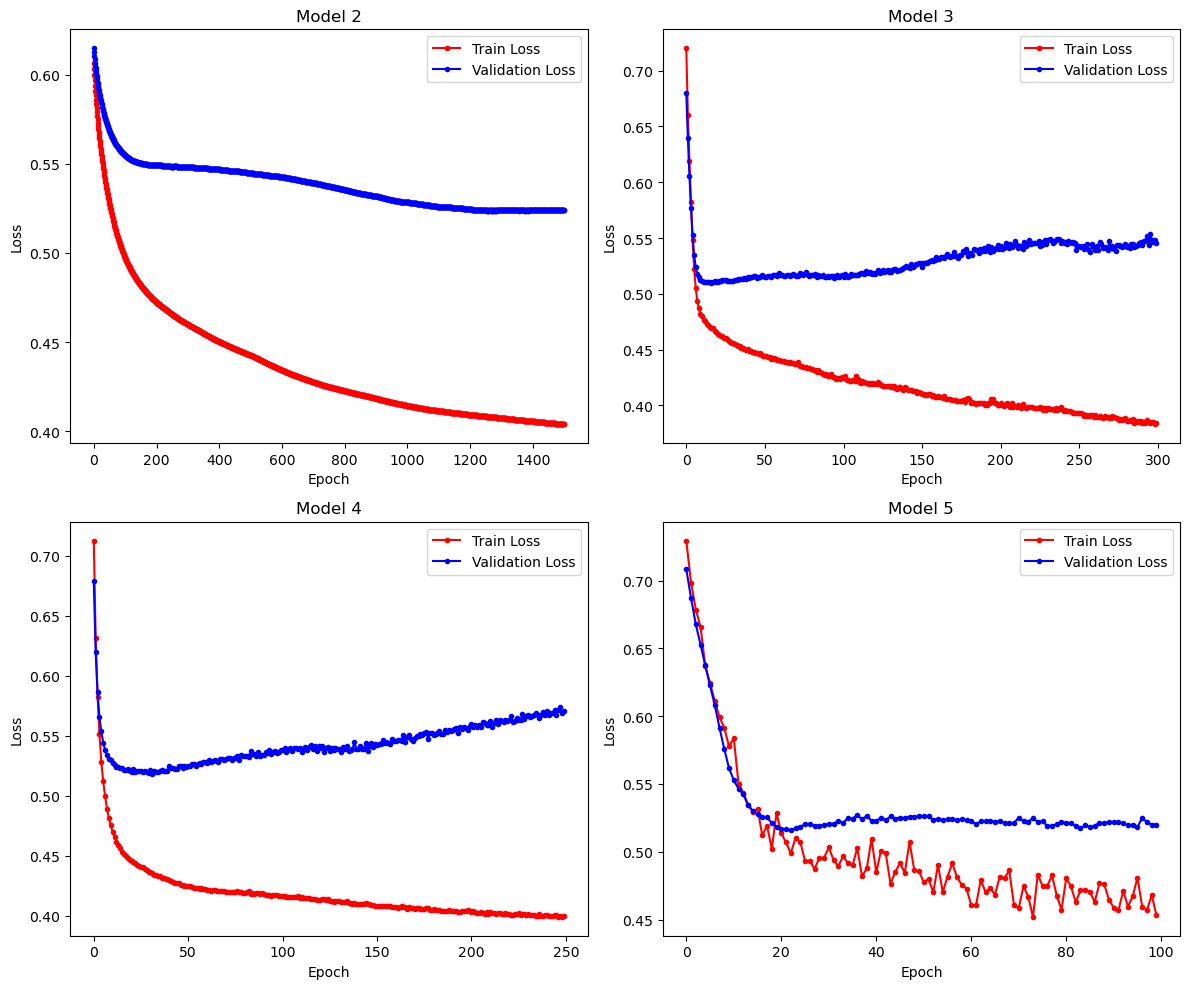

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

histories = [run_hist_2, run_hist_3, run_hist_4, run_hist_5]
titles = ["Model 2", "Model 3", "Model 4", "Model 5"]

for ax, hist, title in zip(axes.flatten(), histories, titles):
    ax.plot(hist.history["loss"], 'r', marker='.', label="Train Loss")
    ax.plot(hist.history["val_loss"], 'b', marker='.', label="Validation Loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

<b> Based on these models that I have tested, it seems that the initial model (Model 1) created seems to have the best results compared to these four where there are changes made in the neural networks.

#### Conclusion

<b>In this hands-on activity, the neural networks are trained on the Pima Indians Diabetes dataset to evaluate their ability to classify the outcome of diabetes. Based on the initial neural network given, it seems to have the best results while remaining simple and concise. We are also tasked to graph the training and validation loss curves to identify whether the model did a great job or not in classifying the outcomes. We also evaluated the models using the ROC curve and AUC values to measure whether the model is good at distinguishing diabetic and non-diabetic cases. Overall, the activities demonstrate that building a simple and effective model with proper data preprocessing and using metrics to determine its accuracy is important in making great neural network models.